### Import Libraries

In [13]:
# data manipulation
import pandas as pd

# visualization
from matplotlib import pyplot as plt
import seaborn as sns

# loading files
import os

### Load and combine all csv files

In [14]:
# set directory to folder containing the data
os.chdir('/Users/aadityaparanjape/Downloads/IDX Exchange/data')

# create a list of all the csv files
files = [file for file in os.listdir()] 

# concatenate all csv files
df = pd.concat(map(pd.read_csv, files), ignore_index=True)

# save combined df as a csv file for later ease of use
df.to_csv('Combined_Housing_Data.csv')

# reset current directory to directory of folder
os.chdir('/Users/aadityaparanjape/Downloads/IDX Exchange')

/var/folders/28/5mb82d2n1z12vmhr2fmv5bb80000gn/T/ipykernel_15712/707452966.py:8: DtypeWarning: Columns (4,74) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat(map(pd.read_csv, files), ignore_index=True)


### Restrict Analysis

In [15]:
# read combined csv
data = pd.read_csv('data/Combined_Housing_Data.csv')
data.head()

,Unnamed: 0,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,...,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
0,0,ContraCosta,ContraCosta,"Carpet,Tile,Wood",NaN,NaN,NaN,False,1998000.0,1150041639,...,NaN,10080.0,NaN,False,3.0,San Ramon Valley,94596,975.0,10080.0,NaN
1,1,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,NaN,1150038872,...,NaN,5663.0,NaN,NaN,5.0,Other,95018,NaN,5663.0,NaN
2,2,SanDiego,SanDiego,"Carpet,Wood",True,NaN,NaN,False,2214421.0,1150038683,...,NaN,34745.0,NaN,False,3.0,NaN,91364,NaN,34745.0,NaN
3,3,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,1200000.0,1150038607,...,NaN,6600.0,NaN,False,2.0,Other,95121,NaN,6600.0,NaN
4,4,TriCounties,TriCounties,NaN,True,NaN,NaN,True,3300.0,1150038314,...,NaN,17500.0,4.0,False,2.0,Jurupa Unified,92509,0.0,17500.0,NaN


In [16]:
# filter data for specific PropertyType and PropertySubType values
filtered_data = data[(data['PropertyType'] == 'Residential') & (data['PropertySubType'] == 'SingleFamilyResidence')]
filtered_data = filtered_data.drop(columns=['Unnamed: 0']) # drop unnecessary column
filtered_data.reset_index(drop = True, inplace=True)
filtered_data.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
0,ContraCosta,ContraCosta,"Carpet,Tile,Wood",NaN,NaN,NaN,False,1998000.0,1150041639,teresa@teresahooper.com,...,NaN,10080.0,NaN,False,3.0,San Ramon Valley,94596,975.0,10080.0,NaN
1,SanDiego,SanDiego,"Carpet,Wood",True,NaN,NaN,False,2214421.0,1150038683,laura@lauralothianrealestate.com,...,NaN,34745.0,NaN,False,3.0,NaN,91364,NaN,34745.0,NaN
2,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,1200000.0,1150038607,trung.lam@kw.com,...,NaN,6600.0,NaN,False,2.0,Other,95121,NaN,6600.0,NaN
3,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,3100000.0,1150032869,vickie@realsmartgroup.com,...,NaN,8262.0,NaN,False,1.0,San Jose Unified,95124,NaN,8262.0,NaN
4,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,2900000.0,1150028403,vickie@realsmartgroup.com,...,NaN,9222.0,NaN,False,2.0,Other,95128,NaN,9222.0,NaN


In [17]:
filtered_data.columns

Index(['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN',
       'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey',
       'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName',
       'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress',
       'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket',
       'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName',
       'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName',
       'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName',
       'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea',
       'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount',
       'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric',
       'ListingId', 'BathroomsTotalInteger', 'City', '

### Visualizations

In [18]:
# create lists for each variation of each variable, when applicable
bedroom_vars = [col for col in filtered_data.columns if 'bedroom' in col.lower() 
                and filtered_data[col].dtype in ['int64', 'float64']]

lotSize_vars = [col for col in filtered_data.columns if 'lotsize' in col.lower() 
                and filtered_data[col].dtype in ['int64', 'float64']]

single_vars = ['ClosePrice', 'LivingArea', 'BathroomsTotalInteger'] # these variables have no variations

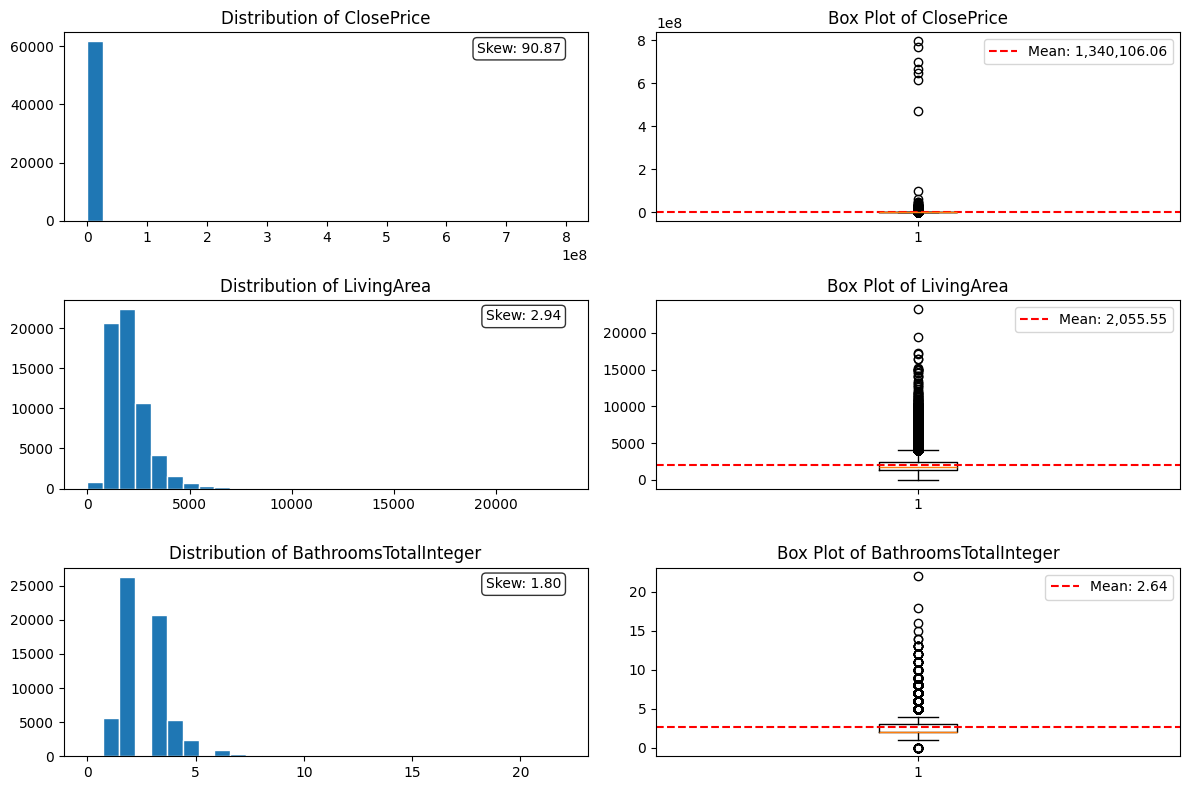

count    6.172700e+04
mean     1.340106e+06
std      7.307629e+06
min      1.750000e+00
25%      6.200000e+05
50%      8.900000e+05
75%      1.425000e+06
max      7.960000e+08
Name: ClosePrice, dtype: float64

count    61697.000000
mean      2055.552918
std       1037.243701
min          0.000000
25%       1386.000000
50%       1826.000000
75%       2455.000000
max      23314.000000
Name: LivingArea, dtype: float64

count    61726.000000
mean         2.644801
std          1.135026
min          0.000000
25%          2.000000
50%          2.000000
75%          3.000000
max         22.000000
Name: BathroomsTotalInteger, dtype: float64



In [19]:
# histograms and boxplots of single vars
fig, axes = plt.subplots(len(single_vars), 2, figsize = (12,8))

# generate plots
for i, col in enumerate(single_vars):
    filtered_col = filtered_data[col].dropna()

    # histograms
    axes[i, 0].hist(filtered_col, bins = 30, edgecolor = 'white')
    axes[i, 0].set_title(f'Distribution of {col}')

    # skew textbox
    skew = filtered_col.skew()
    axes[i, 0].text(
        0.95, 0.95,                          
        f'Skew: {skew:.2f}',
        transform=axes[i, 0].transAxes,      
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )
    
    # boxplots
    axes[i, 1].boxplot(filtered_col)
    axes[i, 1].axhline(filtered_data[col].mean(skipna=True), color = 'red', linestyle = '--', 
                       label = f'Mean: {filtered_data[col].mean(skipna=True):,.2f}')
    axes[i, 1].set_title(f'Box Plot of {col}')
    axes[i, 1].legend()

plt.tight_layout(); plt.show()

for col in single_vars:
    print(filtered_data[col].describe())
    print()

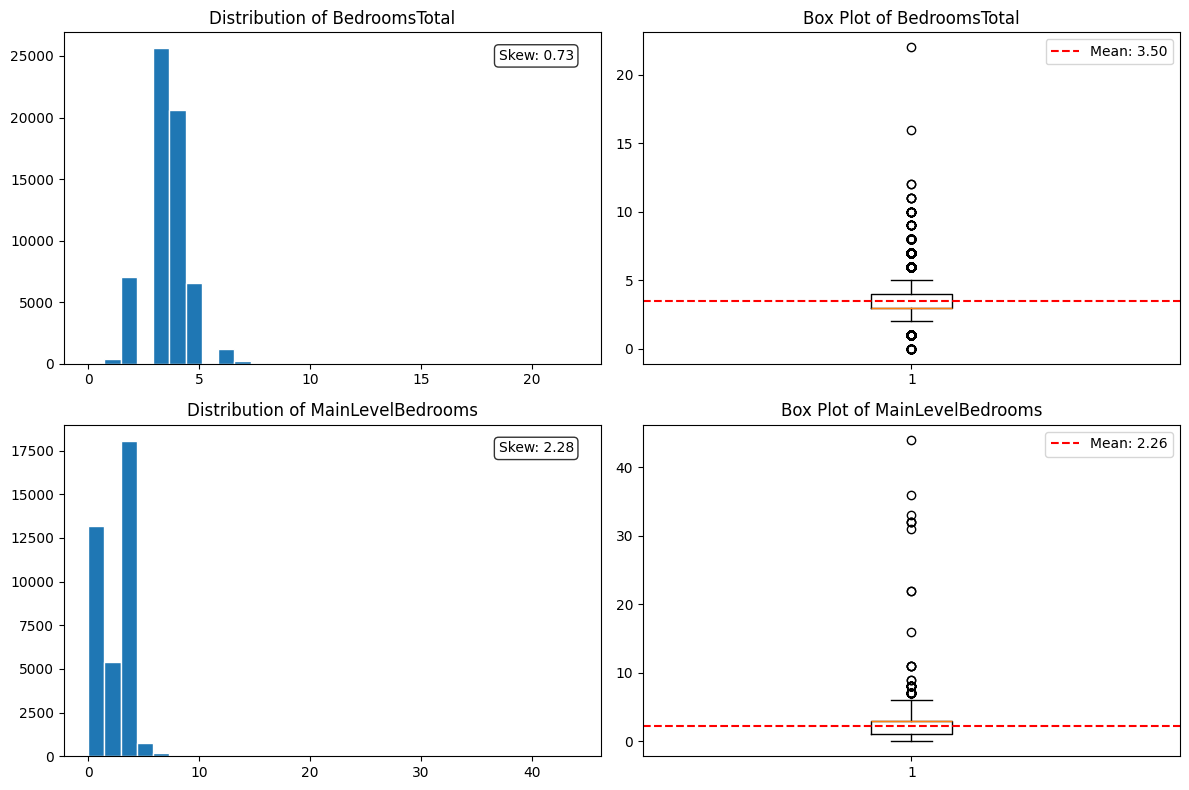

count    61727.000000
mean         3.498437
std          0.966684
min          0.000000
25%          3.000000
50%          3.000000
75%          4.000000
max         22.000000
Name: BedroomsTotal, dtype: float64

count    37653.000000
mean         2.264521
std          1.447379
min          0.000000
25%          1.000000
50%          3.000000
75%          3.000000
max         44.000000
Name: MainLevelBedrooms, dtype: float64



In [20]:
# histograms and boxplots for bedroom variables
fig, axes = plt.subplots(len(bedroom_vars), 2, figsize = (12,8))

# generate plots
for i, col in enumerate(bedroom_vars):
    filtered_col = filtered_data[col].dropna()

    # histograms
    axes[i, 0].hist(filtered_col, bins = 30, edgecolor = 'white')
    axes[i, 0].set_title(f'Distribution of {col}')
    
    # skew textbox
    skew = filtered_col.skew()
    axes[i, 0].text(
        0.95, 0.95,                          
        f'Skew: {skew:.2f}',
        transform=axes[i, 0].transAxes,      
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

    # boxplots
    axes[i, 1].boxplot(filtered_col)
    axes[i, 1].axhline(filtered_data[col].mean(), color = 'red', linestyle = '--', 
                       label = f'Mean: {filtered_data[col].mean():,.2f}')
    axes[i, 1].set_title(f'Box Plot of {col}')
    axes[i, 1].legend()

plt.tight_layout(); plt.show()
    
for col in bedroom_vars:
    print(filtered_data[col].describe())
    print()

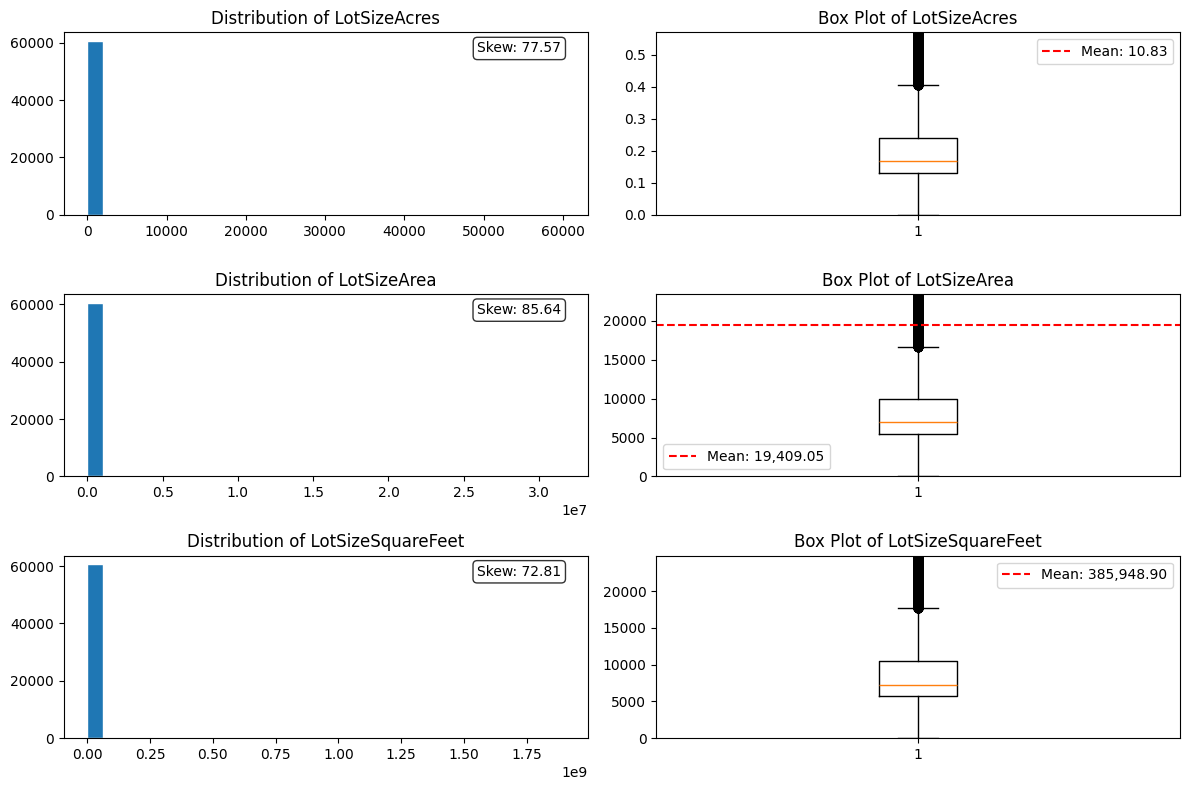

count    60644.000000
mean        10.828569
std        544.530184
min          0.000000
25%          0.130000
50%          0.166800
75%          0.240000
max      60113.000000
Name: LotSizeAcres, dtype: float64

count    6.064900e+04
mean     1.940905e+04
std      2.052488e+05
min      0.000000e+00
25%      5.392000e+03
50%      7.023000e+03
75%      9.900000e+03
max      3.164242e+07
Name: LotSizeArea, dtype: float64

count    6.064600e+04
mean     3.859489e+05
std      1.843401e+07
min      0.000000e+00
25%      5.663000e+03
50%      7.263500e+03
75%      1.045400e+04
max      1.897474e+09
Name: LotSizeSquareFeet, dtype: float64



In [25]:
# histograms and boxplots for LotSize variables
fig, axes = plt.subplots(len(lotSize_vars), 2, figsize = (12,8))

# generate plots
for i, col in enumerate(lotSize_vars):
    filtered_col = filtered_data[col].dropna()

    # histograms
    axes[i, 0].hist(filtered_col, bins = 30, edgecolor = 'white')
    axes[i, 0].set_title(f'Distribution of {col}')
    
    # skew textbox
    skew = filtered_col.skew()
    axes[i, 0].text(
        0.95, 0.95,                          
        f'Skew: {skew:.2f}',
        transform=axes[i, 0].transAxes,      
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

    # boxplots
    axes[i, 1].boxplot(filtered_col)
    axes[i, 1].axhline(filtered_data[col].mean(), color = 'red', linestyle = '--', 
                       label = f'Mean: {filtered_data[col].mean():,.2f}')
    axes[i, 1].set_title(f'Box Plot of {col}')
    axes[i, 1].legend()

    # adjust y-axis scale so we can see the boxes (due to the number of outliers)
    Q1, Q3 = filtered_col.quantile(0.25), filtered_col.quantile(0.75)
    IQR = Q3 - Q1
    axes[i, 1].set_ylim(0, Q3 + 3 * IQR)

plt.tight_layout(); plt.show()   

for col in lotSize_vars:
    print(filtered_data[col].describe())
    print()